<a href="https://colab.research.google.com/github/Alexis-Casanova/challenge-alura-store/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
...,...,...,...,...,...,...,...,...,...,...,...,...
2354,Iphone 15,Electrónicos,1284400.0,66600.0,15/11/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
2355,Impresora,Electrónicos,282800.0,15300.0,18/03/2023,Lucas Olivera,Bogotá,5,Nequi,1,4.60971,-74.08175
2356,Juego de mesa,Juguetes,122900.0,7200.0,06/07/2021,Lucas Olivera,Cali,5,Tarjeta de crédito,4,3.43722,-76.52250
2357,Cama box,Muebles,691300.0,35000.0,02/05/2022,Pedro Gomez,Pasto,1,Tarjeta de crédito,2,1.21361,-77.28111


In [ ]:
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

df_total = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

#1. Análisis de facturación



In [ ]:
tiendaIngresoTotal = df_total.groupby('Tienda')['Precio'].sum()
print("--- Ingreso Total por Tienda ---")
print(tiendaIngresoTotal)

print("\n\n --- Ingreso Neto por Tienda ---")
tiendaIngresoNeto = df_total.groupby('Tienda')['Precio'].sum() - df_total.groupby('Tienda')['Costo de envío'].sum()
print(tiendaIngresoNeto)

--- Ingreso Total por Tienda ---
Tienda
Tienda 1    1.150880e+09
Tienda 2    1.116344e+09
Tienda 3    1.098020e+09
Tienda 4    1.038376e+09
Name: Precio, dtype: float64


 --- Ingreso Neto por Tienda ---
Tienda
Tienda 1    1.089502e+09
Tienda 2    1.056858e+09
Tienda 3    1.039503e+09
Tienda 4    9.830583e+08
dtype: float64


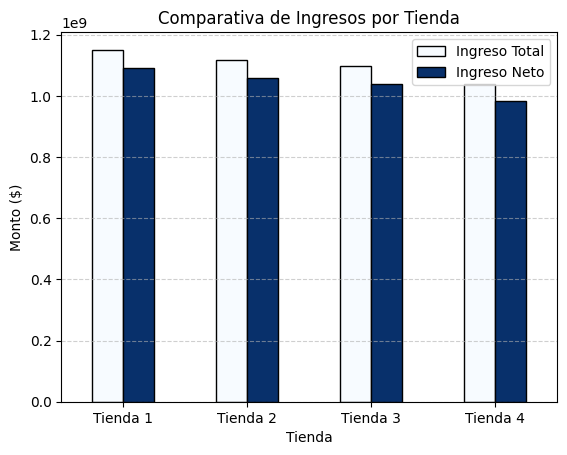

In [ ]:
from matplotlib import pyplot as plt

df_comparativo = pd.DataFrame({
    'Ingreso Total': tiendaIngresoTotal,
    'Ingreso Neto': tiendaIngresoNeto
})

df_comparativo.plot(kind='bar', colormap='Blues', edgecolor='black', rot=0)

plt.title('Comparativa de Ingresos por Tienda')
plt.ylabel('Monto ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 2. Ventas por categoría

In [ ]:
ventas_por_categoria = df_total.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad Vendida')

ventas_por_categoria = ventas_por_categoria.sort_values(by=['Tienda', 'Cantidad Vendida'], ascending=[True, False])
print("--- Ventas por Categoría ---")
print(ventas_por_categoria)


--- Ventas por Categoría ---
      Tienda   Categoría del Producto  Cantidad Vendida
7   Tienda 1                  Muebles               465
3   Tienda 1             Electrónicos               448
5   Tienda 1                 Juguetes               324
2   Tienda 1        Electrodomésticos               312
1   Tienda 1     Deportes y diversión               284
4   Tienda 1   Instrumentos musicales               182
6   Tienda 1                   Libros               173
0   Tienda 1  Artículos para el hogar               171
15  Tienda 2                  Muebles               442
11  Tienda 2             Electrónicos               422
13  Tienda 2                 Juguetes               313
10  Tienda 2        Electrodomésticos               305
9   Tienda 2     Deportes y diversión               275
12  Tienda 2   Instrumentos musicales               224
14  Tienda 2                   Libros               197
8   Tienda 2  Artículos para el hogar               181
23  Tienda 3       

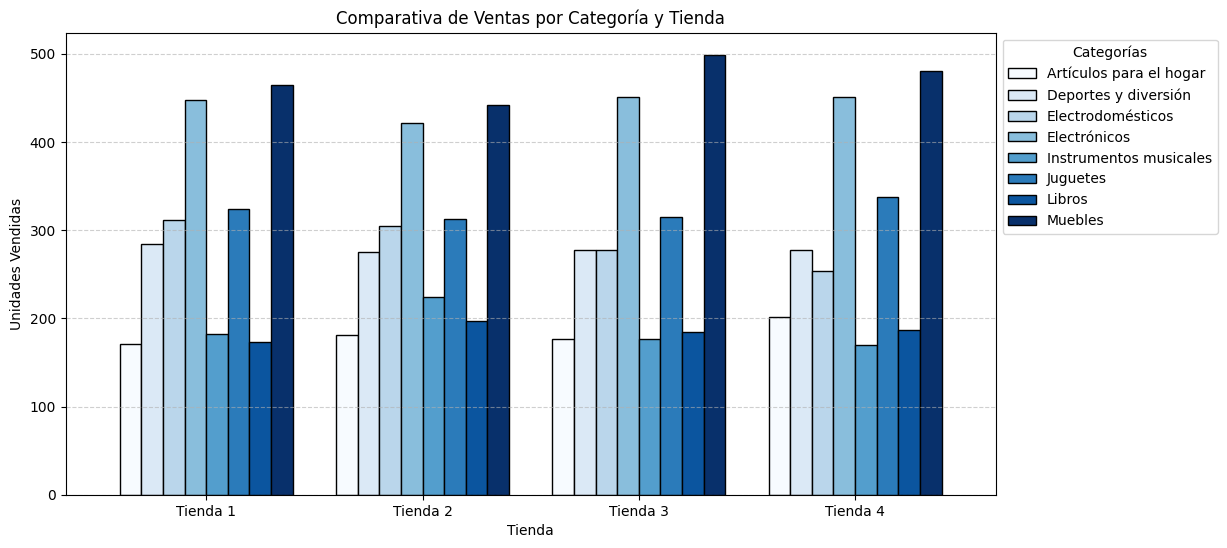

In [ ]:
import matplotlib.pyplot as plt

# Pivote para poder verlas como "columnas"
df_pivot = ventas_por_categoria.pivot(index='Tienda', columns='Categoría del Producto', values='Cantidad Vendida')
# Gráfico
df_pivot.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='Blues', edgecolor='black')

plt.title('Comparativa de Ventas por Categoría y Tienda')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=0)
plt.legend(title='Categorías', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 3. Calificación promedio de la tienda


In [ ]:
calificacion_por_tienda = df_total.groupby('Tienda')['Calificación'].mean().reset_index()

calificacion_por_tienda = calificacion_por_tienda.sort_values(by='Calificación', ascending=False)
print("--- Calificación promedio por Tienda ---")
print(calificacion_por_tienda)


--- Calificación promedio por Tienda ---
     Tienda  Calificación
2  Tienda 3      4.048326
1  Tienda 2      4.037304
3  Tienda 4      3.995759
0  Tienda 1      3.976685


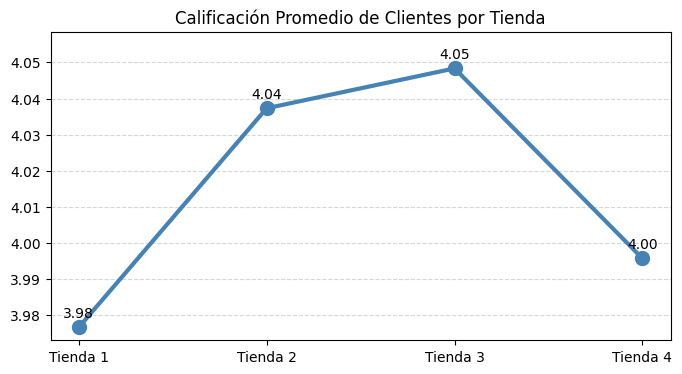

In [ ]:
# Datos ordenados
df = calificacion_por_tienda.sort_values('Tienda')

plt.figure(figsize=(8, 4))
plt.plot(df['Tienda'], df['Calificación'], marker='o', ms=10, lw=3, color='steelblue')

# Para los nombres
for x, y in zip(df['Tienda'], df['Calificación']):
    plt.text(x, y + 0.002, f'{y:.2f}', ha='center', va='bottom')

plt.title('Calificación Promedio de Clientes por Tienda')
plt.ylim(top=df['Calificación'].max() + 0.01)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 4. Productos más y menos vendidos

In [ ]:
ventas_productos = df_total.groupby(['Tienda', 'Producto']).size().reset_index(name='Cantidad')

mas_vendidos = ventas_productos.loc[ventas_productos.groupby('Tienda')['Cantidad'].idxmax()]

menos_vendidos = ventas_productos.loc[ventas_productos.groupby('Tienda')['Cantidad'].idxmin()]

print("--- Productos Más Vendidos por Tienda ---")
print(mas_vendidos)
print("\n\n--- Productos Menos Vendidos por Tienda ---")
print(menos_vendidos)

--- Productos Más Vendidos por Tienda ---
       Tienda                   Producto  Cantidad
1    Tienda 1                    Armario        60
75   Tienda 2  Iniciando en programación        65
129  Tienda 3              Kit de bancas        57
163  Tienda 4                   Cama box        62


--- Productos Menos Vendidos por Tienda ---
       Tienda                   Producto  Cantidad
4    Tienda 1  Auriculares con micrófono        33
77   Tienda 2              Juego de mesa        32
111  Tienda 3    Bloques de construcción        35
175  Tienda 4         Guitarra eléctrica        33


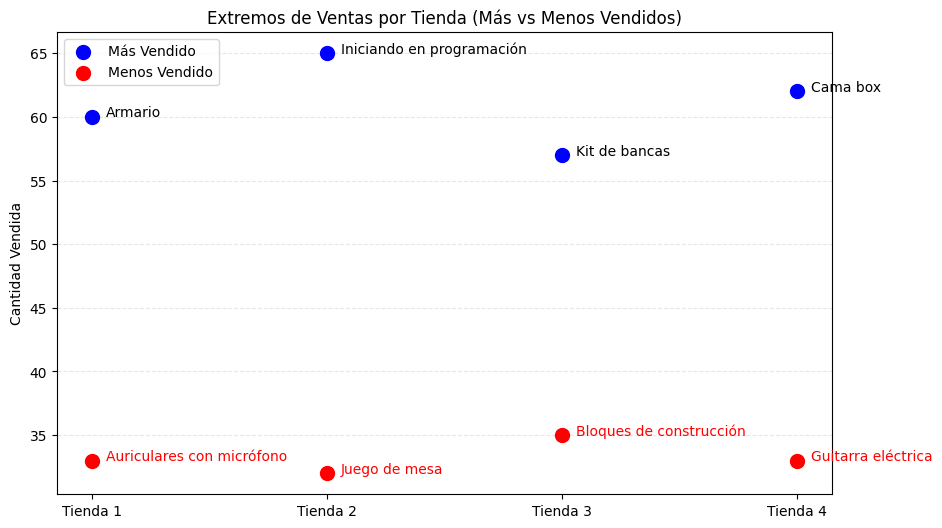

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(mas_vendidos['Tienda'], mas_vendidos['Cantidad'], color='blue', s=100, label='Más Vendido', zorder=3)
plt.scatter(menos_vendidos['Tienda'], menos_vendidos['Cantidad'], color='red', s=100, label='Menos Vendido', zorder=3)

for i, row in mas_vendidos.iterrows():
    plt.annotate(row['Producto'], (row['Tienda'], row['Cantidad']), xytext=(10, 0), textcoords='offset points', color='black')

for i, row in menos_vendidos.iterrows():
    plt.annotate(row['Producto'], (row['Tienda'], row['Cantidad']), xytext=(10, 0), textcoords='offset points', color='red')

plt.title('Extremos de Ventas por Tienda (Más vs Menos Vendidos)')
plt.ylabel('Cantidad Vendida')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

# 5. Envío promedio por tienda

In [ ]:
envio_promedio = df_total.groupby('Tienda')['Costo de envío'].mean().reset_index()

envio_promedio = envio_promedio.sort_values(by='Costo de envío', ascending=False)

print("--- Costo de Envío Promedio pagado por el cliente ---")
print(envio_promedio)

--- Costo de Envío Promedio pagado por el cliente ---
     Tienda  Costo de envío
0  Tienda 1    26018.609580
1  Tienda 2    25216.235693
2  Tienda 3    24805.680373
3  Tienda 4    23459.457167


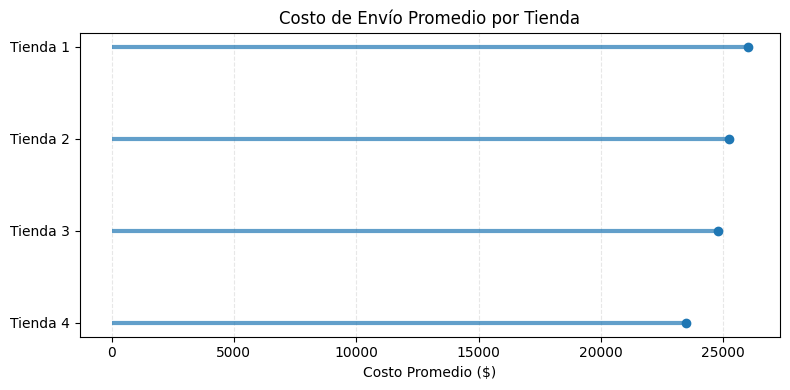

In [ ]:
# Ordenar por costo
envio_promedio = envio_promedio.sort_values('Costo de envío')

plt.figure(figsize=(8, 4))

plt.hlines(
    envio_promedio['Tienda'],
    0,
    envio_promedio['Costo de envío'],
    linewidth=3,
    alpha=0.7
)

plt.plot(
    envio_promedio['Costo de envío'],
    envio_promedio['Tienda'],
    'o'
)

plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Costo Promedio ($)')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


---

#  Informe de Análisis Estratégico: Evaluación de Desinversión de Activos

**Para:** Sr. Juan, CEO de Alura Store  
**Asunto:** Recomendación estratégica sobre la venta de una sucursal para financiamiento de nuevo proyecto.  

---

## 1. Introducción y Contexto

El presente informe tiene como objetivo proporcionar una base sólida y basada en datos para una decisión crítica de negocio: **determinar qué tienda de la cadena Alura Store debe ser vendida**.

El Sr. Juan requiere liberar capital para iniciar un nuevo emprendimiento. Para maximizar la eficiencia del grupo restante y minimizar el impacto negativo en los ingresos globales, la estrategia consiste en **identificar y liquidar la sucursal con el rendimiento integral más bajo**.

Para ello, hemos sometido a las cuatro tiendas a un análisis exhaustivo en cuatro pilares fundamentales:
1.  **Salud Financiera:** Capacidad de generación de flujo de caja y ganancias netas.
2.  **Calidad y Fidelización:** Satisfacción del cliente medida a través de calificaciones.
3.  **Eficiencia Operativa:** Competitividad en costos logísticos (envíos).
4.  **Desempeño de Producto:** Volumen de ventas en categorías clave.

---

## 2. Desarrollo y Análisis de Datos

A continuación, detallamos los hallazgos que sustentan nuestra recomendación final.

### A. Desempeño Financiero (Ingresos)
El análisis de facturación revela una disparidad significativa entre las sucursales, permitiéndonos clasificar las tiendas por su aporte económico al grupo.

* **Líder del Mercado (Tienda 1):** Esta sucursal es el motor financiero de la empresa. Con ingresos totales de **~$1,150 millones** y una ganancia neta de **~$1,089 millones**, representa la fuente de liquidez más importante. Venderla sería un error estratégico grave, ya que comprometería el flujo de caja principal de la cadena.
* **El Eslabón Débil (Tienda 4):** Los datos muestran que la Tienda 4 tiene el desempeño más bajo del grupo. Sus ingresos totales (**~$1,038 millones**) y, más preocupante aún, sus ingresos netos (**~$983 millones**), la sitúan en el último lugar.
    * *Insight Clave:* Existe una brecha de facturación de **$112 millones** entre la Tienda 1 y la Tienda 4. Mantener operativa una tienda que rinde un 10% menos que la líder, consumiendo recursos similares, es ineficiente.

### B. Satisfacción del Cliente (Experiencia de Usuario)
La reputación de marca es un activo intangible crucial.

* **Tienda 3 (El Referente de Calidad):** Ostenta la calificación promedio más alta (**4.05 / 5.00**). Esto indica una base de clientes leal y satisfecha. Desprenderse de esta tienda pondría en riesgo la imagen de marca de Alura Store.
* **Tienda 4 (Mediocridad):** Con un puntaje de **3.99**, se ubica en un terreno intermedio. No tiene la excelencia de la Tienda 3 ni el volumen de ventas que justifique la baja calificación de la Tienda 1 (3.98). Es una tienda que no destaca en servicio.

### C. Eficiencia Logística y Competitividad
Se analizó el costo de envío promedio como un factor de atracción para el cliente.

* **La Paradoja de la Tienda 4:** Esta sucursal ofrece el envío más económico del mercado (**$23,459** promedio).
* **Análisis Crítico:** A pesar de tener la ventaja competitiva de precios bajos en logística, la Tienda 4 **no logra convertir esta ventaja en mayores ventas**. Esto es un síntoma alarmante: si una tienda es "barata" para el cliente pero aun así vende menos que las demás, indica problemas estructurales en su oferta de productos o en su ubicación comercial que no se solucionarán fácilmente.

### D. Análisis de Inventario
La categoría "Muebles" y "Electrónicos" son los pilares de facturación. Mientras que las Tiendas 1, 2 y 3 mantienen volúmenes altos y constantes en estos sectores, la Tienda 4 muestra un estancamiento relativo, incapaz de alcanzar los picos de venta unitaria de sus competidoras internas.

---

## 3. Conclusión y Recomendación Estratégica

Tras ponderar los factores financieros, operativos y de reputación, la conclusión es clara y unidireccional.

### Decisión Recomendada: VENDER LA TIENDA 4

Esta recomendación no se basa en un solo factor, sino en la convergencia de múltiples indicadores negativos:

1.  **Criterio de Rentabilidad:** Es la **única tienda que no supera la barrera de los $1,000 millones** en ingresos netos. Al venderla, el Sr. Juan se deshace del activo con menor retorno sobre la inversión.
2.  **Criterio de Eficiencia Comercial:** La Tienda 4 ha demostrado ser incapaz de atraer volumen de ventas, incluso teniendo la ventaja de envíos económicos. Esto sugiere que su potencial de crecimiento es limitado comparado con las otras sucursales.
3.  **Protección del Núcleo del Negocio:**
    * Al conservar la **Tienda 1**, se asegura el flujo de dinero (Cash Cow).
    * Al conservar la **Tienda 3**, se asegura el prestigio de la marca.
    * La **Tienda 4** no es ni líder en dinero ni líder en prestigio, lo que la convierte en el activo ideal para ser liquidado y capitalizar el nuevo emprendimiento.

**Próximos Pasos Sugeridos:**
Proceder con la valoración comercial de la Tienda 4 y ponerla en venta, utilizando los fondos obtenidos para el nuevo proyecto, mientras se centralizan los esfuerzos de mejora logística en las Tiendas 1, 2 y 3.